In [4]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from google.colab import drive

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project") #put you project path here
assert PROJECT_ROOT.exists(), "PROJECT_ROOT not found"
print("PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
assert DATA_DIR.exists(), "data/ not found"
print("DATA_DIR:", DATA_DIR)

META_DIR = PROJECT_ROOT / "meta"
assert META_DIR.exists(), "meta/ not found"
print("META_DIR:", META_DIR)





Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project
DATA_DIR: /content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project/data
META_DIR: /content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project/meta


In [7]:
import pandas as pd
from pathlib import Path

# to get image_id, split и class (no pneumo/pneumo)
TRAIN_CSV = DATA_DIR / "stage_1_train_images.csv"
TEST_CSV  = DATA_DIR / "stage_1_test_images.csv"

# PREPROCESSED relative paths (from project root)
IMG_DIR = Path("data") / "pre" / "img"
MASK_DIR = Path("data") / "pre" / "masks"

train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)

def build_df(df_csv, split):
    image_id = df_csv["new_filename"].str.replace(".png", "", regex=False)
    return pd.DataFrame({
        "image_id": image_id,
        "img_path":  (IMG_DIR  / image_id.str.cat([".npy"] * len(image_id))).astype(str),
        "mask_path": (MASK_DIR / image_id.str.cat([".npy"] * len(image_id))).astype(str),
        "split": split,
        "status": "U",           # initially all unlabeled
        "round_added": pd.NA,    # null = still unlabeled
        "patient_id": image_id,  # 1 image = 1 patient
        "class": df_csv["has_pneumo"].astype("int8"),
    })

train_df = build_df(train, "train")
test_df  = build_df(test,  "test")

manifest = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

OUT_MANIFEST = META_DIR / "manifest.parquet"
manifest.to_parquet(OUT_MANIFEST, index=False)

print("Wrote:", OUT_MANIFEST)
manifest.head()


Wrote: /content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project/meta/manifest.parquet


,image_id,img_path,mask_path,split,status,round_added,patient_id,class
0,0_train_0_,data/pre/img/0_train_0_.npy,data/pre/masks/0_train_0_.npy,train,U,<NA>,0_train_0_,0
1,1_train_0_,data/pre/img/1_train_0_.npy,data/pre/masks/1_train_0_.npy,train,U,<NA>,1_train_0_,0
2,2_train_1_,data/pre/img/2_train_1_.npy,data/pre/masks/2_train_1_.npy,train,U,<NA>,2_train_1_,1
3,3_train_1_,data/pre/img/3_train_1_.npy,data/pre/masks/3_train_1_.npy,train,U,<NA>,3_train_1_,1
4,4_train_1_,data/pre/img/4_train_1_.npy,data/pre/masks/4_train_1_.npy,train,U,<NA>,4_train_1_,1


In [8]:

from pathlib import Path
root = Path("/content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project/data/pre")
imgs = list((root/"img").glob("*.npy"))
masks = list((root/"masks").glob("*.npy"))
print("imgs:", len(imgs))
print("masks:", len(masks)) # should be equal length



imgs: 12047
masks: 12047


In [ ]:
from pathlib import Path

img_ids  = {p.stem for p in (root/"img").glob("*.npy")}
mask_ids = {p.stem for p in (root/"masks").glob("*.npy")}

print("Equal sets:", img_ids == mask_ids)


Equal sets: True


In [ ]:
"""from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import albumentations as A
# =========================
# Preproc configs
# =========================
PREPROC_DIR = Path("preproc")
PREPROC_IMG_DIR = PREPROC_DIR / "images"
PREPROC_MASK_DIR = PREPROC_DIR / "masks"
PREPROC_IMG_DIR.mkdir(parents=True, exist_ok=True)
PREPROC_MASK_DIR.mkdir(parents=True, exist_ok=True)

OUT_MANIFEST_PREPROC = Path("meta/manifest_preproc.parquet")

EXPECT_HW = (1024, 1024)
TARGET_HW = (512, 512)  # (H, W)


preproc_tf = A.Compose(
    [
        A.Resize(height=TARGET_HW[0], width=TARGET_HW[1], interpolation=cv2.INTER_LINEAR),
    ],
    additional_targets={"mask": "mask"},
)

img_paths = []
mask_paths = []

for i, row in enumerate(manifest.itertuples(index=False)):
    img = cv2.imread(row.img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE)
    mask = (mask>0).astype(np.uint8)

    if img.shape != mask.shape:
        raise RuntimeError(f"Shape mismatch for {row.image_id}: {img.shape} vs {mask.shape}")
    if img.shape != EXPECT_HW:
        raise RuntimeError(f"Unexpected size for {row.image_id}: {img.shape}, expected {EXPECT_HW}")

    # Normalize [0,1]
    img = img.astype(np.float16) / 255.0

    out = preproc_tf(image=img, mask=mask)
    img = out["image"]
    mask = out["mask"]

    img_out = PREPROC_IMG_DIR / f"{row.image_id}.npy"
    mask_out = PREPROC_MASK_DIR / f"{row.image_id}.npy"

    np.save(img_out, img)
    np.save(mask_out, mask)

    img_paths.append(str(img_out))
    mask_paths.append(str(mask_out))

    if i % 500 == 0:
        print(f"Processed {i} samples")

df_out = manifest[["image_id", "split", "status", "round_added"]].copy()
df_out["img_preproc_path"] = img_paths
df_out["mask_preproc_path"] = mask_paths

df_out.to_parquet(OUT_MANIFEST_PREPROC, index=False)

print("Done.")
"""

Processed 0 samples
Processed 500 samples
Processed 1000 samples
Processed 1500 samples
Processed 2000 samples
Processed 2500 samples
Processed 3000 samples
Processed 3500 samples
Processed 4000 samples
Processed 4500 samples
Processed 5000 samples
Processed 5500 samples
Processed 6000 samples
Processed 6500 samples
Processed 7000 samples
Processed 7500 samples
Processed 8000 samples
Processed 8500 samples
Processed 9000 samples
Processed 9500 samples
Processed 10000 samples
Processed 10500 samples
Processed 11000 samples
Processed 11500 samples
Processed 12000 samples
Done.


In [12]:
# add val split

import numpy as np
import pandas as pd
from pathlib import Path

SEED = 42
VAL_FRAC = 0.1

PROJECT_ROOT = Path("/content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project")
manifest_path = PROJECT_ROOT / "meta" / "manifest.parquet"

df = pd.read_parquet(manifest_path)

# only from current train
train_idx = df.index[df["split"] == "train"].to_numpy()

df_train = df.loc[train_idx].copy()
rng = np.random.default_rng(SEED)

val_indices = []

for cls in [0, 1]:
    idx = df_train.index[df_train["class"] == cls].to_numpy()
    rng.shuffle(idx)

    n_val = int(round(len(idx) * VAL_FRAC))

    val_indices.append(idx[:n_val])

val_indices = np.concatenate(val_indices) if len(val_indices) else np.array([], dtype=int)

# assign split
df.loc[val_indices, "split"] = "val"

# print summary
print("Split counts:")
print(df["split"].value_counts())
print("\nClass counts by split:")
print(pd.crosstab(df["split"], df["class"]))

# save back
df.to_parquet(manifest_path, index=False)
print("\nWrote:", manifest_path)


Split counts:
split
train    9607
test     1372
val      1068
Name: count, dtype: int64

Class counts by split:
class     0     1
split            
test   1082   290
train  7466  2141
val     830   238

Wrote: /content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project/meta/manifest.parquet


In [15]:
# show 5 examples where df['split'] = "val"
df[df["split"] == "val"].sample(5)



,image_id,img_path,mask_path,split,status,round_added,patient_id,class
6476,6476_train_0_,data/pre/img/6476_train_0_.npy,data/pre/masks/6476_train_0_.npy,val,U,None,6476_train_0_,0
8136,8136_train_0_,data/pre/img/8136_train_0_.npy,data/pre/masks/8136_train_0_.npy,val,U,None,8136_train_0_,0
9014,9014_train_0_,data/pre/img/9014_train_0_.npy,data/pre/masks/9014_train_0_.npy,val,U,None,9014_train_0_,0
4099,4099_train_1_,data/pre/img/4099_train_1_.npy,data/pre/masks/4099_train_1_.npy,val,U,None,4099_train_1_,1
10227,10227_train_0_,data/pre/img/10227_train_0_.npy,data/pre/masks/10227_train_0_.npy,val,U,None,10227_train_0_,0


We created a stratified train/validation. The validation set contains enough  positive samples to ensure stable Dice evaluation in active learning rounds.

Columns: ['image_id', 'img_path', 'mask_path', 'split', 'status', 'round_added', 'patient_id', 'class']

Class counts:
 class
0    9378
1    2669
Name: count, dtype: int64


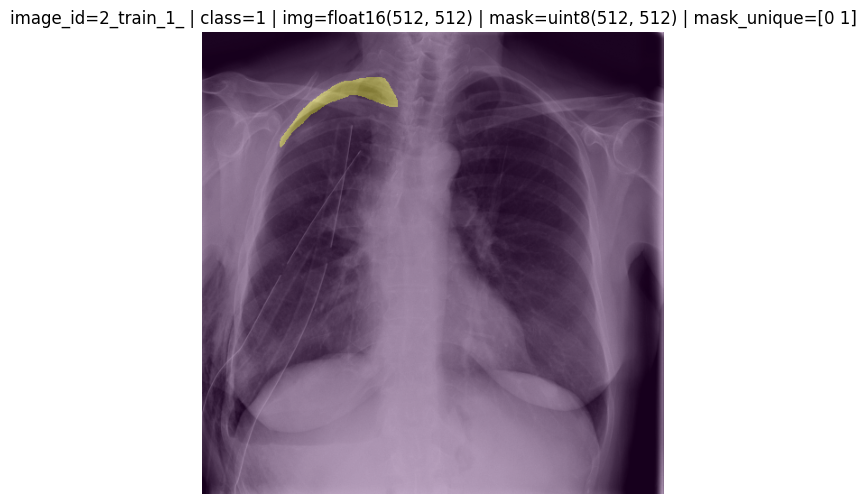

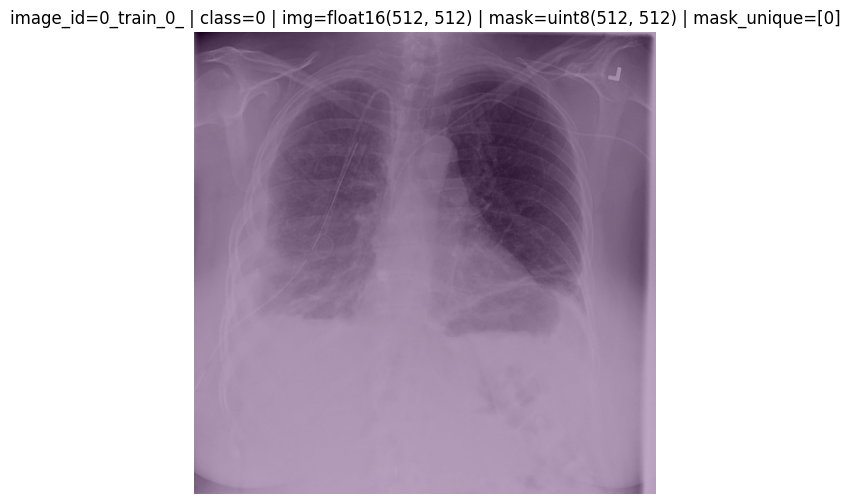

Split counts:
split
train    9607
test     1372
val      1068
Name: count, dtype: int64

Class counts by split:
class     0     1
split            
test   1082   290
train  7466  2141
val     830   238


In [16]:

import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project")
MANIFEST = PROJECT_ROOT / "meta" / "manifest.parquet"

df = pd.read_parquet(MANIFEST)

# required columns
need = {"image_id", "img_path", "mask_path", "class"}
missing_cols = need - set(df.columns)
if missing_cols:
    raise KeyError(f"manifest.parquet is missing columns: {missing_cols}\n"
                   f"Current cols: {df.columns.tolist()}")

print("Columns:", df.columns.tolist())
print("\nClass counts:\n", df["class"].value_counts(dropna=False))

# pick one positive and one negative
pos = df[df["class"] == 1].iloc[0] if (df["class"] == 1).any() else None
neg = df[df["class"] == 0].iloc[0] if (df["class"] == 0).any() else None

def show_row(r):
    img_fp = PROJECT_ROOT / r["img_path"] if not str(r["img_path"]).startswith("/") else Path(r["img_path"])
    mask_fp = PROJECT_ROOT / r["mask_path"] if not str(r["mask_path"]).startswith("/") else Path(r["mask_path"])

    if not img_fp.exists():
        raise FileNotFoundError(f"Image not found: {img_fp}")
    if not mask_fp.exists():
        raise FileNotFoundError(f"Mask not found: {mask_fp}")

    img = np.load(img_fp)
    mask = np.load(mask_fp)

    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.imshow(mask, alpha=0.35)
    plt.title(
        f"image_id={r['image_id']} | class={r['class']} | "
        f"img={img.dtype}{img.shape} | mask={mask.dtype}{mask.shape} | "
        f"mask_unique={np.unique(mask)}"
    )
    plt.axis("off")
    plt.show()

if pos is not None:
    show_row(pos)

if neg is not None:
    show_row(neg)


print("Split counts:")
print(df["split"].value_counts())
print("\nClass counts by split:")
print(pd.crosstab(df["split"], df["class"]))

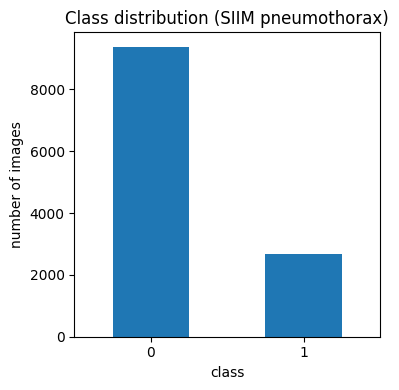

In [17]:

counts = df["class"].value_counts()

plt.figure(figsize=(4, 4))
counts.plot(kind="bar")

plt.xlabel("class")
plt.ylabel("number of images")
plt.title("Class distribution (SIIM pneumothorax)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [19]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from pathlib import Path

class PneumoDataset(Dataset):
    def __init__(self, manifest_path, split="train", project_root=None):
        self.df = pd.read_parquet(manifest_path)
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)

        self.project_root = Path(project_root) if project_root is not None else None

    def __len__(self):
        return len(self.df)

    def _resolve(self, p): # function to resolve the paths when reading manifest, since there it looks like "data/pre/masks/6476_train_0_.npy"
        p = Path(p)
        if p.is_absolute():
            return p
        if self.project_root is None:
            return p
        return self.project_root / p

    def __getitem__(self, idx):
        r = self.df.iloc[idx]

        img_path = self._resolve(r["img_path"])
        mask_path = self._resolve(r["mask_path"])

        img = np.load(img_path).astype(np.float32)
        mask = np.load(mask_path).astype(np.float32)

        img = torch.from_numpy(img).unsqueeze(0)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return img, mask


In [20]:
train_ds = PneumoDataset(
    manifest_path="/content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project/meta/manifest.parquet",
    split="train",
    project_root=PROJECT_ROOT
)
val_ds = PneumoDataset(
    manifest_path="/content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project/meta/manifest.parquet",
    split="val",
    project_root=PROJECT_ROOT
)
test_ds = PneumoDataset(
    manifest_path="/content/drive/MyDrive/UNIVR/ADVANCED_PROGRAMMING/project/meta/manifest.parquet",
    split="test",
    project_root=PROJECT_ROOT
)


In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0)

print("train size:", len(train_ds))
print("val size:", len(val_ds))
print("test size:", len(test_ds))


train size: 9607
val size: 1068
test size: 1372


In [22]:
imgs, masks = next(iter(train_loader))
print("imgs:", imgs.shape, imgs.dtype, imgs.min().item(), imgs.max().item())
print("masks:", masks.shape, masks.dtype, torch.unique(masks))



imgs: torch.Size([8, 1, 512, 512]) torch.float32 0.0 1.0
masks: torch.Size([8, 1, 512, 512]) torch.float32 tensor([0., 1.])


In [23]:


print("TOTAL:", len(df))
print("\nBy split:")
print(df["split"].value_counts())

print("\nClass by split:")
print(pd.crosstab(df["split"], df["class"], dropna=False))


TOTAL: 12047

By split:
split
train    9607
test     1372
val      1068
Name: count, dtype: int64

Class by split:
class     0     1
split            
test   1082   290
train  7466  2141
val     830   238


In train and validation sets we keep the proportion of the classes equal.

In [24]:
print("Train class ratio:")
print(df[df["split"]=="train"]["class"].value_counts(normalize=True))
print("\nVal class ratio:")
print(df[df["split"]=="val"]["class"].value_counts(normalize=True))


Train class ratio:
class
0    0.777142
1    0.222858
Name: proportion, dtype: float64

Val class ratio:
class
0    0.777154
1    0.222846
Name: proportion, dtype: float64


In [25]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class MyUNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.down1 = DoubleConv(1, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.mid = DoubleConv(32, 64)

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv2 = DoubleConv(32 + 32, 32)

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.conv1 = DoubleConv(16 + 16, 16)

        self.out = nn.Conv2d(16, 1, 1)  # logits

    def forward(self, x):
        x1 = self.down1(x)      # (B,16,512,512)
        x = self.pool1(x1)      # (B,16,256,256)
        x2 = self.down2(x)      # (B,32,256,256)
        x = self.pool2(x2)      # (B,32,128,128)

        x = self.mid(x)         # (B,64,128,128)

        x = self.up2(x)         # (B,32,256,256)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)         # (B,16,512,512)
        x = torch.cat([x, x1], dim=1)
        x = self.conv1(x)

        return self.out(x)      # (B,1,512,512)


In [26]:
def dice_score_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    # flatten per batch
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * inter + eps) / (union + eps)
    return dice.mean().item()


0 class images are 3.5 times moree than 1st class images. So in BCEWithLogitsLoss we will punish error in positive class 3.5 times more because we dont want the model to predict always class 0. Also we've taken the per-image and not per-pixel ratio, as not to count positive pixels on the whole dataset (the second version is in the commented cell, there the number of positive pixel is 300 times less than negative pixels)

In [27]:
n_pos = (train_df["class"] == 1).sum()
n_neg = (train_df["class"] == 0).sum()
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=device, dtype=torch.float32)
print("pos_weight (image-level approx):", pos_weight.item())


pos_weight (image-level approx): 3.4871795177459717


In [35]:
"""from tqdm.auto import tqdm

pos = 0
neg = 0

pbar = tqdm(train_loader, desc="Computing pos_weight", leave=False)
for _, yb in pbar:
    # count pixels
    batch_pos = (yb > 0.5).sum().item()
    batch_neg = (yb <= 0.5).sum().item()

    pos += batch_pos
    neg += batch_neg


    total = pos + neg
    pos_frac = pos / total if total > 0 else 0.0
    pbar.set_postfix(
        pos_pixels=pos,
        neg_pixels=neg,
        pos_frac=f"{pos_frac:.6f}"
    )

pos_weight = torch.tensor([neg / max(pos, 1)], device=device)

print("=== pos_weight computed ===")
print("pos pixels:", pos)
print("neg pixels:", neg)
print("pos_weight:", pos_weight.item())

NB here the results was

=== pos_weight computed ===
pos pixels: 6833892
neg pixels: 2259663132
pos_weight: 330.6553649902344

"""

Computing pos_weight:   0%|          | 0/1201 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [29]:
#pos_weight = torch.tensor([neg / max(pos, 1)], device=device)
#pos_weight = torch.clamp(pos_weight, max=300.0)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


In [31]:
bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

import torch

def soft_dice_from_logits(logits, targets, eps=1e-6):
    """
    Computes soft Dice over the batch.
    Returns a Python float.
    logits: (B, 1, H, W)
    targets: (B, 1, H, W)
    """
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()

def soft_dice_pos_only_from_logits(logits, targets, eps=1e-6):
    """
    Computes Dice only on images that have at least
    one positive pixel in the target.
    Returns NaN if no positives are present in the batch.
    """
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    has_pos = (targets.sum(dim=1) > 0)

    if has_pos.sum() == 0:
        return float("nan")

    probs = probs[has_pos]
    targets = targets[has_pos]

    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + eps) / (union + eps)
    return dice.mean().item()


def soft_dice_loss_from_logits(logits,targets,smooth =1.0):
    """
    logits:  (B, 1, H, W) raw model outputs (NO sigmoid)
    targets: (B, 1, H, W) binary masks {0,1}, float32
    """
    probs = torch.sigmoid(logits)

    # flatten per image
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)

    dice = (2.0 * intersection + smooth) / (union + smooth)
    # loss = 1 - Dice
    return 1.0 - dice.mean()


def combined_loss(logits, targets, dice_weight=1.0):
    # dice_weight to establish: you can try 0.5..2.0
    return bce(logits, targets) + dice_weight * soft_dice_loss_from_logits(logits, targets)


In [ ]:
import math
import torch
from tqdm.auto import tqdm

# device / model / optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyUNet().to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 3
DICE_WEIGHT = 1.0
CLIP_NORM = 1.0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_soft_dice": [],
    "val_soft_dice_pos": [],
    "train_pos_frac": [],
}

for epoch in range(EPOCHS):

    # TRAIN

    model.train()
    train_loss_sum = 0.0
    train_pos_sum = 0.0
    n_train = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    for x, y in pbar:
        x = x.to(device)
        y = y.to(device)

        bs = x.size(0)
        pos_frac = (y > 0.5).float().mean().item()

        opt.zero_grad()

        logits = model(x)
        loss = combined_loss(logits, y, dice_weight=DICE_WEIGHT)
        loss.backward()

        # optional gradient clipping
        #torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)

        opt.step()

        train_loss_sum += loss.item() * bs
        train_pos_sum += pos_frac * bs
        n_train += bs

        pbar.set_postfix(
            loss=f"{(train_loss_sum / max(n_train,1)):.4f}",
            pos_frac=f"{(train_pos_sum / max(n_train,1)):.6f}"
        )

    train_loss = train_loss_sum / max(n_train, 1)
    train_pos = train_pos_sum / max(n_train, 1)

    history["train_loss"].append(train_loss)
    history["train_pos_frac"].append(train_pos)


    # VAL

    model.eval()
    val_loss_sum = 0.0
    val_dice_sum = 0.0
    val_dice_pos_sum = 0.0
    n_val = 0
    n_val_pos_batches = 0  # counting batches used for dice_pos averaging

    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]")
    with torch.no_grad():
        for x, y in pbar:
            x = x.to(device)
            y = y.to(device)
            bs = x.size(0)

            logits = model(x)
            vloss = combined_loss(logits, y, dice_weight=DICE_WEIGHT)

            if not torch.isfinite(vloss):
                continue


            batch_dice = soft_dice_from_logits(logits, y)  # average over batch
            batch_dice_pos = soft_dice_pos_only_from_logits(logits, y)  # NaN if no positives

            val_loss_sum += vloss.item() * bs
            val_dice_sum += float(batch_dice) * bs
            n_val += bs

            if not (isinstance(batch_dice_pos, float) and math.isnan(batch_dice_pos)):
                val_dice_pos_sum += float(batch_dice_pos) * bs
                n_val_pos_batches += bs

            avg_vloss = val_loss_sum / max(n_val, 1)
            avg_dice = val_dice_sum / max(n_val, 1)
            avg_dice_pos = val_dice_pos_sum / n_val_pos_batches if n_val_pos_batches > 0 else float("nan")

            pbar.set_postfix(
                vloss=f"{avg_vloss:.4f}",
                dice=f"{avg_dice:.4f}",
                dice_pos=("nan" if math.isnan(avg_dice_pos) else f"{avg_dice_pos:.4f}")
            )

    val_loss = val_loss_sum / max(n_val, 1)
    val_dice = val_dice_sum / max(n_val, 1)
    val_dice_pos = val_dice_pos_sum / n_val_pos_batches if n_val_pos_batches > 0 else float("nan")

    history["val_loss"].append(val_loss)
    history["val_soft_dice"].append(val_dice)
    history["val_soft_dice_pos"].append(val_dice_pos)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_soft_dice={val_dice:.4f} | "
        f"val_soft_dice_pos={'nan' if math.isnan(val_dice_pos) else f'{val_dice_pos:.4f}'}"
    )


Epoch 1/3 [train]:   0%|          | 0/1201 [00:00<?, ?it/s]

In [ ]:
model.parameters

<bound method Module.parameters of MyUNet(
  (down1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (mid): DoubleConv(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(in

In [ ]:
import os
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(
    {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": opt.state_dict(),
        "pos_weight": pos_weight.cpu(),
        "history": history,
    },
    f"{SAVE_DIR}/unet_last.pt"
)


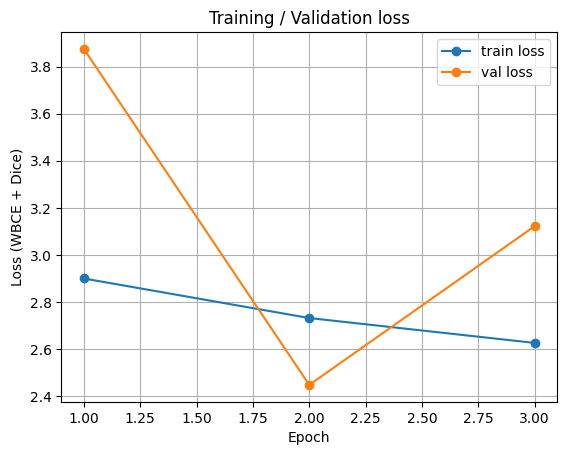

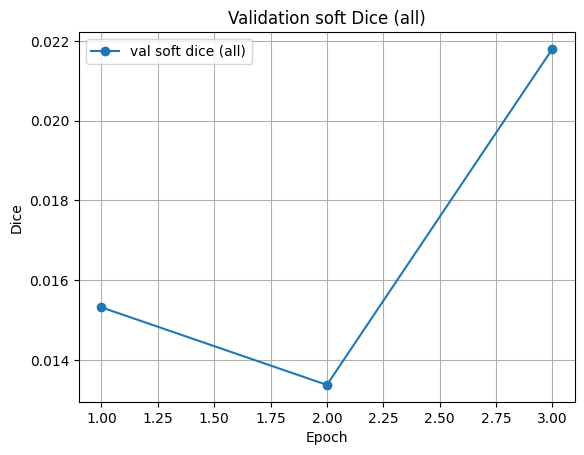

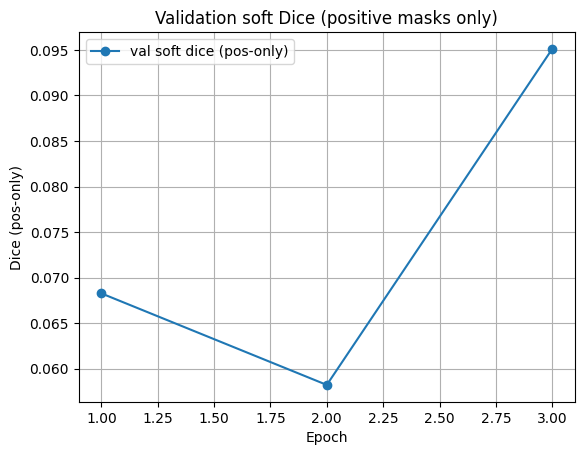

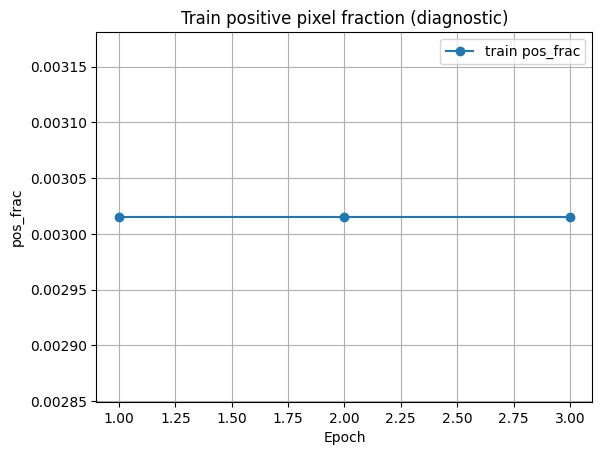

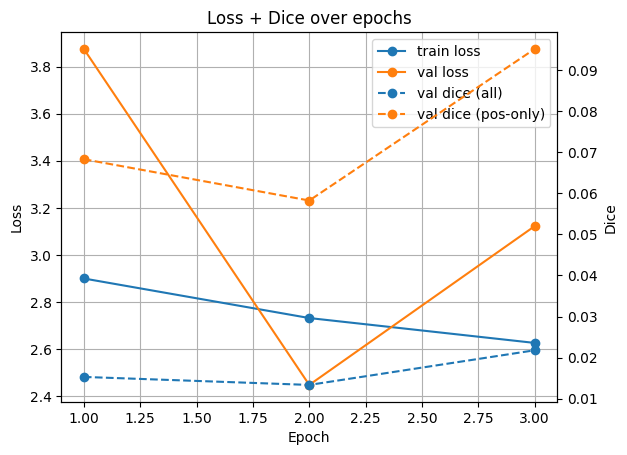

In [ ]:
import math
import matplotlib.pyplot as plt

epochs = list(range(1, len(history["train_loss"]) + 1))

# 1) Loss curves
plt.figure()
plt.plot(epochs, history["train_loss"], marker="o", label="train loss")
plt.plot(epochs, history["val_loss"], marker="o", label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (WBCE + Dice)")
plt.title("Training / Validation loss")
plt.grid(True)
plt.legend()
plt.show()

# 2) Dice curves (val)
plt.figure()
plt.plot(epochs, history["val_soft_dice"], marker="o", label="val soft dice (all)")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Validation soft Dice (all)")
plt.grid(True)
plt.legend()
plt.show()

# 3) Dice_pos curve (val)
dice_pos = history["val_soft_dice_pos"]
dice_pos_clean = [v if (v is not None and isinstance(v, (int, float)) and not math.isnan(v)) else None for v in dice_pos]

plt.figure()
plt.plot(epochs, dice_pos_clean, marker="o", label="val soft dice (pos-only)")
plt.xlabel("Epoch")
plt.ylabel("Dice (pos-only)")
plt.title("Validation soft Dice (positive masks only)")
plt.grid(True)
plt.legend()
plt.show()

# 4) Train positive pixel fraction (diagnostic)
plt.figure()
plt.plot(epochs, history["train_pos_frac"], marker="o", label="train pos_frac")
plt.xlabel("Epoch")
plt.ylabel("pos_frac")
plt.title("Train positive pixel fraction (diagnostic)")
plt.grid(True)
plt.legend()
plt.show()

# 5) Combined plot (loss + dice on two axes)
fig, ax1 = plt.subplots()
ax1.plot(epochs, history["train_loss"], marker="o", label="train loss")
ax1.plot(epochs, history["val_loss"], marker="o", label="val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(epochs, history["val_soft_dice"], marker="o", linestyle="--", label="val dice (all)")
ax2.plot(epochs, dice_pos_clean, marker="o", linestyle="--", label="val dice (pos-only)")
ax2.set_ylabel("Dice")

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Loss + Dice over epochs")
plt.show()


In [ ]:
"""During the first 3 epochs, training loss decreases.
Validation dice increases, meaning that the model begins to recognize pneumothorax regions.
Validation loss is non-monotonic."""